<a href="https://colab.research.google.com/github/BegoAN/IMAGES_IA_/blob/SUCIO/Plantitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELDA 1 - Instalación y carga del dataset
!pip install datasets -q

from datasets import load_dataset

# Plan B si "default" también falla
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git
dataset = load_dataset("imagefolder", data_dir="PlantVillage-Dataset/raw/color")

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 28.21 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


Resolving data files:   0%|          | 0/54305 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Número de imágenes: 54305
Clases: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted

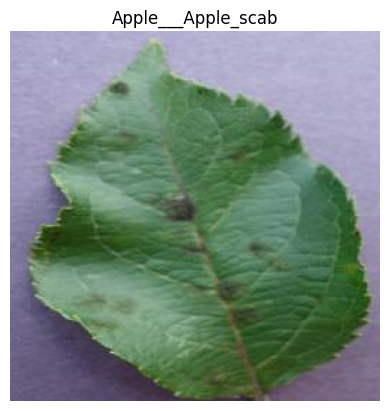

In [ ]:
# CELDA 2 - Exploración básica
train_data = dataset["train"]
print("Número de imágenes:", len(train_data))
print("Clases:", train_data.features["label"].names)
print("Número de clases:", len(train_data.features["label"].names))

# Ver una imagen de ejemplo
import matplotlib.pyplot as plt

ejemplo = train_data[0]
plt.imshow(ejemplo["image"])
plt.title(train_data.features["label"].int2str(ejemplo["label"]))
plt.axis("off")
plt.show()

In [ ]:
# CELDA 3 - Función de preprocesamiento
import numpy as np
from PIL import Image

IMG_SIZE = 128

def preprocesar_imagen(img):
    img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    array = np.array(img) / 255.0
    return array

# Prueba rápida
img_procesada = preprocesar_imagen(ejemplo["image"])
print("Forma:", img_procesada.shape)
print("Rango:", img_procesada.min(), "-", img_procesada.max())

Forma: (128, 128, 3)
Rango: 0.023529411764705882 - 0.8705882352941177


Para un TFG, lo estándar en preprocesamiento de imágenes (más allá de resize/normalize) es:

Eliminación de duplicados / casi-duplicados: se usa "perceptual hashing" (no un hash exacto tipo MD5, porque dos fotos casi iguales tienen bytes distintos). La librería típica es imagehash (funciona sobre PIL). Comparas hashes y descartas imágenes con distancia muy baja entre sí.
Detección de imágenes corruptas/ilegibles: comprobar que Image.open() no falla, filtrar imágenes demasiado pequeñas o completamente negras/blancas.
Balanceo de clases: PlantVillage no está balanceado (hay clases con muchas más imágenes que otras) — esto se analiza pero normalmente no se "corrige" en el preprocesamiento, se maneja después con class weights o data augmentation dirigida a las clases minoritarias.
Normalización de color/iluminación: a veces se aplica ecualización de histograma (CLAHE) para que la iluminación no afecte tanto.
Data augmentation (rotar, flip, zoom, cambios de brillo): esto NO se hace en el preprocesamiento inicial, se aplica solo al train set y normalmente dentro del pipeline de entrenamiento (ImageDataGenerator de Keras o torchvision.transforms), nunca al test set.
Segmentación del fondo (opcional, más avanzado): PlantVillage ya trae una versión "segmented" donde recortan la hoja del fondo — puede ser un experimento interesante para tu TFG (comparar accuracy con fondo vs sin fondo).

otra duda, tengo que meter el dataset descargado en alguna parteDeliberó sobre ubicación de caché y opciones de almacenamiento persistenteDeliberó sobre ubicación de caché y opciones de almacenamiento persistenteBuena pregunta. Con el código que te pasé, no tienes que subir tú nada a mano — la línea load_dataset("mohanty/PlantVillage", "color") descarga el dataset automáticamente desde Hugging Face y lo guarda en una carpeta caché interna de la máquina virtual de Colab (algo como /root/.cache/huggingface/datasets). Tú no la tocas, simplemente funciona.
Pero ojo con un detalle importante de cómo funciona Colab:
El problema: cada vez que abres una nueva sesión de Colab (o si se desconecta por inactividad), la máquina virtual se borra entera — incluido el dataset descargado. Así que si cierras y vuelves otro día, tendrías que descargarlo de nuevo (puede tardar varios minutos, el dataset pesa varios GB).
La solución: usar tu Google Drive para persistir los datos entre sesiones. Así lo descargas una vez y luego solo lo lees de tu Drive:
python# CELDA 0 - Conectar Google Drive (ejecuta esto primero, antes de todo lo demás)
from google.colab import drive
drive.mount('/content/drive')

# Crea una carpeta de trabajo para el TFG dentro de tu Drive
import os
carpeta_proyecto = '/content/drive/MyDrive/TFG_plantas'
os.makedirs(carpeta_proyecto, exist_ok=True)
print("Carpeta creada en:", carpeta_proyecto)
Te va a pedir que autorices el acceso a tu cuenta de Google (aparece un enlace, das permiso y ya).
Y entonces, en la CELDA 6 de antes (donde guardábamos los .npy), en vez de guardarlos sueltos en la máquina temporal, los guardas ya directamente en tu Drive:
python# CELDA 6 (modificada) - Guardar en Google Drive, no en la máquina temporal
np.save(f"{carpeta_proyecto}/X_train.npy", X_train)
np.save(f"{carpeta_proyecto}/X_test.npy", X_test)
np.save(f"{carpeta_proyecto}/y_train.npy", y_train)
np.save(f"{carpeta_proyecto}/y_test.npy", y_test)

print("Guardado en Google Drive:", carpeta_proyecto)
Así, la próxima vez que abras Colab, en vez de repetir todo el preprocesamiento, simplemente montas el Drive y cargas los arrays ya listos:
python# Sesión siguiente: cargar directamente sin reprocesar nada
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
carpeta_proyecto = '/content/drive/MyDrive/TFG_plantas'

X_train = np.load(f"{carpeta_proyecto}/X_train.npy")
X_test = np.load(f"{carpeta_proyecto}/X_test.npy")
y_train = np.load(f"{carpeta_proyecto}/y_train.npy")
y_test = np.load(f"{carpeta_proyecto}/y_test.npy")

print("Datos cargados. X_train:", X_train.shape)
Un aviso: si más adelante subes N_MUESTRA a valores altos (todo el dataset con imágenes grandes), los .npy pueden pesar varios GB — revisa que tengas espacio libre en tu Drive (la cuenta gratuita da 15GB).
¿Seguimos con la extracción de features o quieres primero dejar corriendo esto y confirmar que el Drive y el dataset se han guardado bien?Reconciled configuration mismatch between expected and available keysReconciled configuration mismatch between expected and available keysVale, veo el error: BuilderConfig 'color' not found. Available: ['default']. Parece que el dataset en Hugging Face ha cambiado su estructura de configuraciones desde que se documentó. Vamos a comprobarlo rápido.Diagnosed configuration mismatch and identified optimal loading strategyDiagnosed configuration mismatch and identified optimal loading strategyEse es un problema del propio dataset en Hugging Face, no de tu código — parece que han renombrado o simplificado las configuraciones y ahora mismo solo existe la config "default" (aunque la documentación oficial todavía dice "color"). El mensaje de error te lo dice literal: Available: ['default'].
Solución rápida, cambia esa línea:
python# En vez de esto:
# dataset = load_dataset("mohanty/PlantVillage", "color")

# Usa esto:
dataset = load_dataset("mohanty/PlantVillage")
Sin especificar configuración, debería coger la que hay disponible (default) automáticamente.
Vuelve a ejecutar esa celda y dime qué te sale al hacer print(dataset). Si sigue fallando, tenemos un plan B fiable: descargar el dataset directamente de Kaggle (vipoooool/new-plant-diseases-dataset, es una réplica muy usada de PlantVillage) o clonar el repo de GitHub original y cargarlo con imagefolder, que es más robusto que depender de la config exacta de Hugging Face:
python# Plan B si "default" también falla
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git
dataset = load_dataset("imagefolder", data_dir="PlantVillage-Dataset/raw/color")
Prueba primero el cambio simple y me dices el resultado.ahora esta yendo bien ??Evaluó progreso: Plan B avanzando exitosamente con datos procesadosEvaluó progreso: Plan B avanzando exitosamente con datos procesadosSí, esta vez va bien 👍
En la primera imagen ves que el intento con "default" seguía fallando (mismo error que antes, esta vez con el config por defecto). Pero en la segunda imagen se ve que el Plan B funcionó: ha clonado el repo de GitHub correctamente —
Cloning into 'PlantVillage-Dataset'...
Receiving objects: 100% (163264/163264), 2.00 GiB
Resolving deltas: 100% (115/115), done.
— y ahora está generando el split de train con imagefolder: Generating train split: 54305/0 [00:04<00:00, 13211.25 examples/s]. Es decir, ha detectado las 54.305 imágenes correctamente y las está indexando.
Deja que termine esa celda 1 (la barra de progreso "Generating train split" tiene que llegar al 100%, puede tardar uno o dos minutos porque son 2GB de imágenes). Ahora mismo la celda 2 está en estado "Loading..." esperando a que la celda 1 termine — es normal, no la relances ni la toques.
Cuando la celda 1 termine sin errores, la celda 2 se ejecutará sola (o dale a play si no arranca) y deberías ver algo como:
Número de imágenes: 54305
Clases: ['Apple___Apple_scab', 'Apple___Black_rot', ...]
Número de clases: 38
Avísame con el resultado de la celda 2 cuando termine y seguimos con el resto del preprocesamiento.celda 2 ha funcionado ? que pego despues ? y en que documentacion online miro para aplicar cosas de preprocesamiento de imagenes ? tipo eliminar duplicados o no se , que se suele aplicar al preprocesamiento de imagenes ?Validó dataset y compiló recursos para preprocesamiento de imágenesValidó dataset y compiló recursos para preprocesamiento de imágenesSí, la celda 2 ha ido perfecta: 54.305 imágenes, 38 clases, y te ha enseñado bien el ejemplo (Apple___Apple_scab). Todo correcto.
Qué pegar después
Ahora toca el preprocesamiento real. Como el dataset lo tienes cargado con imagefolder en vez de la config de Hugging Face, la función que te pasé antes sigue funcionando igual porque dataset["train"][i]["image"] te sigue dando un objeto PIL. Pega esto a continuación:
python# CELDA 3 - Función de preprocesamiento
import numpy as np
from PIL import Image

IMG_SIZE = 128

def preprocesar_imagen(img):
    img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    array = np.array(img) / 255.0
    return array

# Prueba rápida
img_procesada = preprocesar_imagen(ejemplo["image"])
print("Forma:", img_procesada.shape)
print("Rango:", img_procesada.min(), "-", img_procesada.max())
Y a partir de ahí seguirías con las celdas 4, 5 y 6 que ya te pasé (procesar muestra → train/test split → guardar en Drive). Si quieres, cuando termines esto añadimos ya las técnicas de limpieza que preguntas — pero conviene meterlas antes de convertir a array, es decir, dentro o antes de preprocesar_imagen.
Sobre duplicados y demás — qué se suele aplicar
Para un TFG, lo estándar en preprocesamiento de imágenes (más allá de resize/normalize) es:

Eliminación de duplicados / casi-duplicados: se usa "perceptual hashing" (no un hash exacto tipo MD5, porque dos fotos casi iguales tienen bytes distintos). La librería típica es imagehash (funciona sobre PIL). Comparas hashes y descartas imágenes con distancia muy baja entre sí.
Detección de imágenes corruptas/ilegibles: comprobar que Image.open() no falla, filtrar imágenes demasiado pequeñas o completamente negras/blancas.
Balanceo de clases: PlantVillage no está balanceado (hay clases con muchas más imágenes que otras) — esto se analiza pero normalmente no se "corrige" en el preprocesamiento, se maneja después con class weights o data augmentation dirigida a las clases minoritarias.
Normalización de color/iluminación: a veces se aplica ecualización de histograma (CLAHE) para que la iluminación no afecte tanto.
Data augmentation (rotar, flip, zoom, cambios de brillo): esto NO se hace en el preprocesamiento inicial, se aplica solo al train set y normalmente dentro del pipeline de entrenamiento (ImageDataGenerator de Keras o torchvision.transforms), nunca al test set.
Segmentación del fondo (opcional, más avanzado): PlantVillage ya trae una versión "segmented" donde recortan la hoja del fondo — puede ser un experimento interesante para tu TFG (comparar accuracy con fondo vs sin fondo).

Documentación que te recomiendo mirar (todas fiables y con ejemplos claros):

scikit-image (https://scikit-image.org/docs/stable/) — la librería de referencia en Python para preprocesado "clásico": filtros, ecualización, detección de bordes, segmentación. Muy usada en TFGs de este tipo.
OpenCV-Python tutorials (https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html) — para todo lo de manipulación de imagen más "de bajo nivel" (color spaces, blur, thresholding).
imagehash (https://github.com/JohannesBuchner/imagehash) — específico para detectar duplicados/casi-duplicados.
Albumentations (https://albumentations.ai/docs/) — la librería más usada hoy en día para data augmentation, mejor documentada que las alternativas y con ejemplos específicos de clasificación de imágenes.
Keras preprocessing / ImageDataGenerator (https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) — para cuando llegues a la parte de redes neuronales.


In [ ]:
# ============================================
# PASO 0 - Instalar librería para detectar duplicados
# ============================================
!pip install imagehash -q

import numpy as np
from PIL import Image
import imagehash

IMG_SIZE = 128
N_MUESTRA = 2000  # empieza bajo para probar

train_data = dataset["train"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.1 MB/s eta 0:00:00


In [ ]:
# ============================================
# PASO 1 - AQUÍ BUSCO DUPLICADOS (o casi-duplicados)
# ============================================
# Calculo un "hash perceptual" de cada imagen: dos imágenes
# visualmente parecidas tendrán un hash parecido, aunque no
# sean el archivo exactamente igual (esto es mejor que comparar
# bytes, porque detecta también recortes/compresión distinta)

hashes_vistos = {}
indices_duplicados = []

for i in range(N_MUESTRA):
    img = train_data[i]["image"].convert("RGB")
    h = imagehash.average_hash(img)  # calcula el hash de la imagen

    if h in hashes_vistos:
        # Ya existe una imagen con este mismo hash -> es duplicado
        indices_duplicados.append(i)
    else:
        hashes_vistos[h] = i

print(f"Duplicados encontrados: {len(indices_duplicados)} de {N_MUESTRA}")

Duplicados encontrados: 3 de 2000


In [ ]:
# ============================================
# PASO 2 - AQUÍ LOS ELIMINO
# ============================================
# Me quedo solo con los índices que NO están en la lista de duplicados

indices_validos = [i for i in range(N_MUESTRA) if i not in indices_duplicados]
print(f"Imágenes válidas tras eliminar duplicados: {len(indices_validos)}")

Imágenes válidas tras eliminar duplicados: 1997


In [ ]:
# ============================================
# PASO 3 - AQUÍ REDIMENSIONO Y NORMALIZO
# ============================================
# Cada imagen puede venir en tamaños distintos -> las dejo todas
# igual (128x128) para que el modelo pueda procesarlas.
# Y divido entre 255 para que los valores de color pasen de
# rango [0-255] a rango [0-1] (los modelos entrenan mejor así)

def preprocesar_imagen(img):
    img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    array = np.array(img) / 255.0
    return array

In [ ]:
# ============================================
# PASO 4 - AQUÍ APLICO EL PREPROCESAMIENTO A TODAS LAS IMÁGENES VÁLIDAS
# ============================================

X = []
y = []

for i in indices_validos:
    item = train_data[i]
    X.append(preprocesar_imagen(item["image"]))
    y.append(item["label"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (num_imagenes, 128, 128, 3)
print("y shape:", y.shape)

X shape: (1997, 128, 128, 3)
y shape: (1997,)


In [ ]:
# ============================================
# PASO 5 - AQUÍ DIVIDO EN TRAIN/TEST
# ============================================
# Separo un 80% para entrenar el modelo y un 20% para evaluarlo
# después con imágenes que el modelo no ha visto nunca

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1597, 128, 128, 3) Test: (400, 128, 128, 3)


In [ ]:
# ============================================
# PASO 6 - AQUÍ GUARDO EL RESULTADO EN GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
carpeta_proyecto = '/content/drive/MyDrive/TFG_plantas'
os.makedirs(carpeta_proyecto, exist_ok=True)

np.save(f"{carpeta_proyecto}/X_train.npy", X_train)
np.save(f"{carpeta_proyecto}/X_test.npy", X_test)
np.save(f"{carpeta_proyecto}/y_train.npy", y_train)
np.save(f"{carpeta_proyecto}/y_test.npy", y_test)

print("Guardado en:", carpeta_proyecto)

Mounted at /content/drive
Guardado en: /content/drive/MyDrive/TFG_plantas
